# Overview of the Datasets

In [51]:
import pandas as pd

df = pd.read_csv("quality_of_life_indices_by_country.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Rank                            1495 non-null   int64  
 1   Country                         1495 non-null   object 
 2   Quality of Life Index           1495 non-null   float64
 3   Purchasing Power Index          1495 non-null   float64
 4   Safety Index                    1495 non-null   float64
 5   Health Care Index               1495 non-null   float64
 6   Cost of Living Index            1495 non-null   float64
 7   Property Price to Income Ratio  1495 non-null   float64
 8   Traffic Commute Time Index      1495 non-null   float64
 9   Pollution Index                 1495 non-null   float64
 10  Climate Index                   1495 non-null   object 
 11  Year                            1495 non-null   object 
dtypes: float64(8), int64(1), object(3)

In [52]:
df.head()

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Year
0,1,Switzerland,222.9,146.5,73.2,66.3,126.0,7.3,25.6,24.1,-,2015
1,2,Germany,195.9,111.8,71.5,75.6,76.3,6.6,31.1,28.3,-,2015
2,3,Sweden,193.9,110.9,57.9,76.3,82.9,9.2,26.9,15.1,-,2015
3,4,United States,192.5,126.1,50.0,67.8,76.5,2.6,36.0,31.4,-,2015
4,5,Finland,190.2,101.2,70.5,69.4,89.7,7.0,33.2,14.9,-,2015


In [53]:
import pandas as pd

df = pd.read_csv("world_tourism_.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               4250 non-null   object 
 1   country_code          4250 non-null   object 
 2   year                  4250 non-null   int64  
 3   tourism_receipts      2948 non-null   float64
 4   tourism_arrivals      3235 non-null   float64
 5   tourism_exports       2785 non-null   float64
 6   tourism_departures    1767 non-null   float64
 7   tourism_expenditures  2831 non-null   float64
 8   gdp                   4223 non-null   float64
 9   inflation             4250 non-null   float64
 10  unemployment          4250 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 365.4+ KB


In [54]:
df.head()

,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,Afghanistan,AFG,1999,NaN,NaN,NaN,NaN,NaN,NaN,12.686269,7.903
1,Afghanistan,AFG,2000,NaN,NaN,NaN,NaN,NaN,3.521418e+09,12.686269,7.935
2,Afghanistan,AFG,2001,NaN,NaN,NaN,NaN,NaN,2.813572e+09,12.686269,7.953
3,Afghanistan,AFG,2002,NaN,NaN,NaN,NaN,NaN,3.825701e+09,12.686269,7.930
4,Afghanistan,AFG,2003,NaN,NaN,NaN,NaN,NaN,4.520947e+09,12.686269,7.880


Loading Datasets

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

# Loading csv files
tourism_df = pd.read_csv("world_tourism_.csv")
quality_df = pd.read_csv("quality_of_life_indices_by_country.csv")

# Printing the row and column
print("Tourism shape:", tourism_df.shape)
print("Quality shape:", quality_df.shape)

Tourism shape: (4250, 11)
Quality shape: (1495, 12)


Data Cleaning

In [56]:
# Standardizing country names and year formats
tourism_df["country"] = tourism_df["country"].astype(str).str.strip()
quality_df["Country"] = quality_df["Country"].astype(str).str.strip()

tourism_df["year"] = pd.to_numeric(tourism_df["year"], errors="coerce")
quality_df["Year"] = quality_df["Year"].astype(str).str.strip()

Filtering for year 2015

In [57]:
# We choose 2015 as the common year within 2 datasets to investigate
tourism_2015 = tourism_df[tourism_df["year"] == 2015].copy()
quality_2015 = quality_df[quality_df["Year"] == "2015"].copy()

# Printing the rows and columns
print("Tourism 2015 shape:", tourism_2015.shape)
print("Quality 2015 shape:", quality_2015.shape)

Tourism 2015 shape: (170, 11)
Quality 2015 shape: (86, 12)


Selecting Columns


In [58]:
# Selecting the appropriate columns we will use
tourism_2015 = tourism_2015[["country", "tourism_receipts", "gdp"]].copy()
quality_2015 = quality_2015[["Country", "Safety Index", "Cost of Living Index"]].copy()

# Fixing the different names of the columns
quality_2015 = quality_2015.rename(columns={"Country": "country"})

Missing Values

In [59]:
# Make string values numeric and drop the Null values
tourism_2015["tourism_receipts"] = pd.to_numeric(tourism_2015["tourism_receipts"], errors="coerce")
tourism_2015["gdp"] = pd.to_numeric(tourism_2015["gdp"], errors="coerce")
quality_2015["Safety Index"] = pd.to_numeric(quality_2015["Safety Index"], errors="coerce")
quality_2015["Cost of Living Index"] = pd.to_numeric(quality_2015["Cost of Living Index"], errors="coerce")

# Drop Null values
tourism_2015 = tourism_2015.dropna(subset=["tourism_receipts", "gdp"])
quality_2015 = quality_2015.dropna(subset=["Safety Index", "Cost of Living Index"])

# Avoiding division by zero
tourism_2015 = tourism_2015[tourism_2015["gdp"] > 0].copy()

Avoiding Bias

In [60]:
# Create the new column named tourism_gdp_ratio to avoid bias in bigger countries
tourism_2015["tourism_gdp_ratio"] = tourism_2015["tourism_receipts"] / tourism_2015["gdp"]

print("Tourism ratio summary:")
print(tourism_2015["tourism_gdp_ratio"].describe())

Tourism ratio summary:
count    138.000000
mean       0.068085
std        0.107948
min        0.000770
25%        0.014959
50%        0.029474
75%        0.067750
max        0.651652
Name: tourism_gdp_ratio, dtype: float64


Checking Countries Before Merge

In [61]:
# Checking country names before merge them
tourism_countries = set(tourism_2015["country"])
quality_countries = set(quality_2015["country"])

only_in_tourism = sorted(tourism_countries - quality_countries)
only_in_quality = sorted(quality_countries - tourism_countries)

print("\nCountries only in tourism dataset:", len(only_in_tourism))
print(only_in_tourism[:20])

print("\nCountries only in quality dataset:", len(only_in_quality))
print(only_in_quality[:20])


Countries only in tourism dataset: 74
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Azerbaijan', 'Barbados', 'Benin', 'Bhutan', 'Bosnia and Herzegovina', 'Botswana', 'Burkina Faso', 'Cabo Verde', 'Cameroon', 'Comoros', 'Costa Rica', "Cote d'Ivoire", 'Cuba', 'Czechia', 'Djibouti']

Countries only in quality dataset: 22
['Bosnia And Herzegovina', 'Canada', 'China', 'Czech Republic', 'Egypt', 'Hong Kong', 'Iran', 'Latvia', 'Lithuania', 'Puerto Rico', 'Russia', 'Slovakia', 'South Korea', 'Spain', 'Sweden', 'Taiwan', 'Turkey', 'Turkmenistan', 'United Kingdom', 'United States']


Merging Datasets

In [62]:
# Merging 2 datasets
df = pd.merge(tourism_2015, quality_2015, on="country", how="inner")

print("\nMerged dataset shape:", df.shape)
print(df.head())


Merged dataset shape: (64, 6)
     country  tourism_receipts           gdp  tourism_gdp_ratio  Safety Index  \
0  Argentina      5.441000e+09  5.947493e+11           0.009148          37.6   
1    Armenia      9.560000e+08  1.055334e+10           0.090587          70.9   
2  Australia      3.624900e+10  1.351296e+12           0.026825          57.8   
3    Austria      2.042200e+10  3.795461e+11           0.053806          73.8   
4    Bahrain      2.827000e+09  3.252330e+10           0.086922          60.0   

   Cost of Living Index  
0                  67.1  
1                  40.7  
2                  99.3  
3                  76.9  
4                  56.2  


Final Check before EDA

In [63]:
# Final check before starting EDA
print("Missing values in merged dataset:")
print(df.isnull().sum())

print("Final columns:")
print(df.columns.tolist())

Missing values in merged dataset:
country                 0
tourism_receipts        0
gdp                     0
tourism_gdp_ratio       0
Safety Index            0
Cost of Living Index    0
dtype: int64
Final columns:
['country', 'tourism_receipts', 'gdp', 'tourism_gdp_ratio', 'Safety Index', 'Cost of Living Index']


# EDA

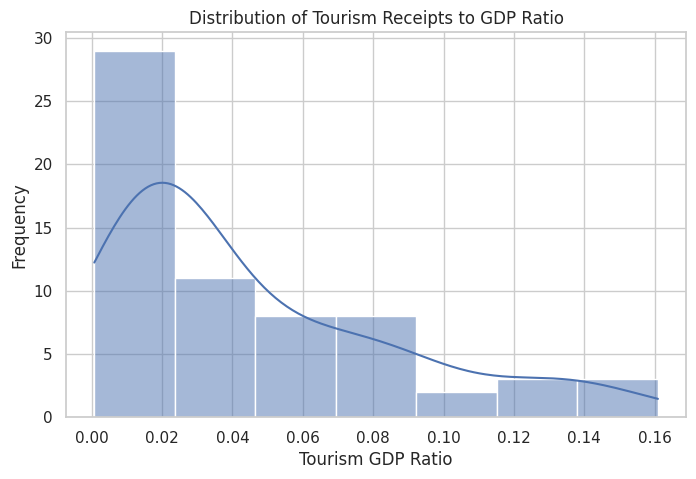

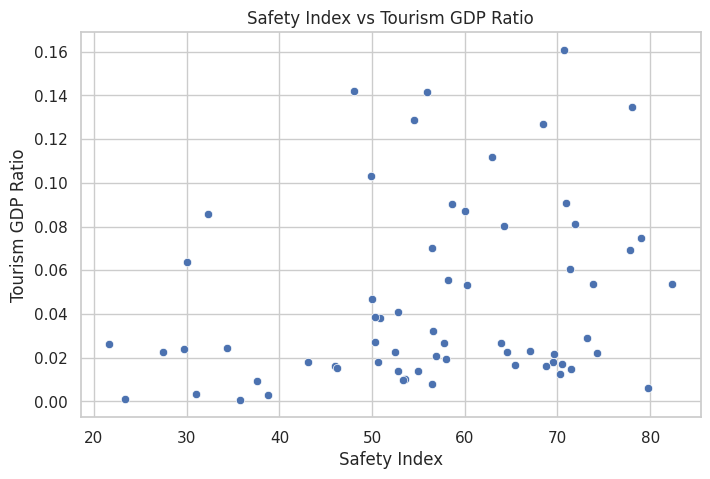

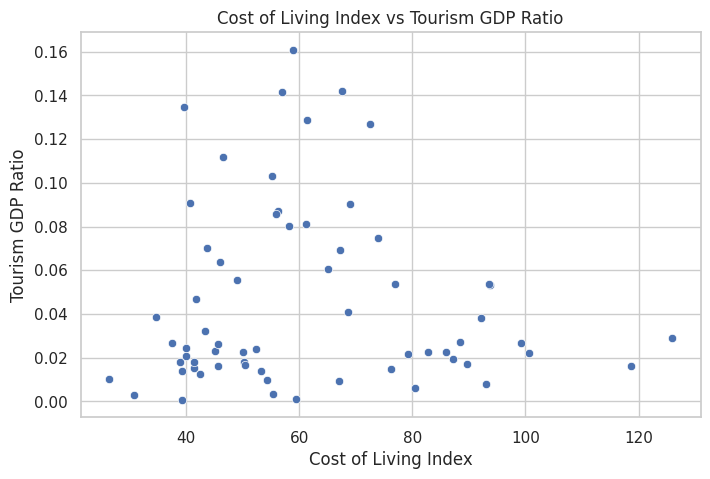

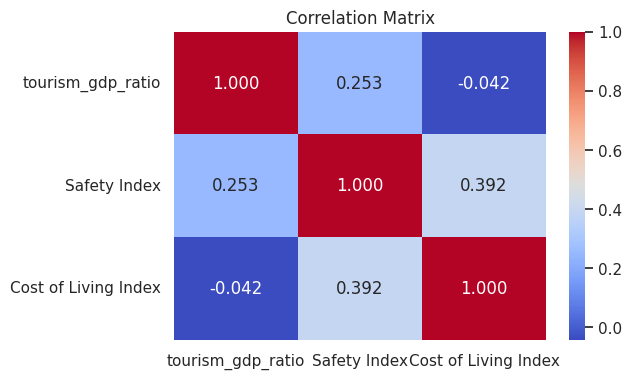

In [64]:
sns.set_theme(style="whitegrid")

# Distribution of tourism_gdp_ratio
plt.figure(figsize=(8, 5))
sns.histplot(df["tourism_gdp_ratio"], kde=True)
plt.title("Distribution of Tourism Receipts to GDP Ratio")
plt.xlabel("Tourism GDP Ratio")
plt.ylabel("Frequency")
plt.show()

# Safety vs tourism scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Safety Index", y="tourism_gdp_ratio")
plt.title("Safety Index vs Tourism GDP Ratio")
plt.xlabel("Safety Index")
plt.ylabel("Tourism GDP Ratio")
plt.show()

# Cost of living vs tourism scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Cost of Living Index", y="tourism_gdp_ratio")
plt.title("Cost of Living Index vs Tourism GDP Ratio")
plt.xlabel("Cost of Living Index")
plt.ylabel("Tourism GDP Ratio")
plt.show()

# Correlation matrix
corr_matrix = df[["tourism_gdp_ratio", "Safety Index", "Cost of Living Index"]].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Matrix")
plt.show()

# Hypothesis Tests

Hypothesis Test 1:


In [65]:
# H1: Higher safety is associated with higher tourism contribution to GDP.
# H0: Higher safety is not associated with higher tourism contribution to GDP.
corr_safety, p_safety = pearsonr(df["Safety Index"], df["tourism_gdp_ratio"])

Hypothesis Test 2:

In [66]:
# H1: Higher cost of living is associated with lower tourism contribution to GDP.
# H0: Higher cost of living is not associated with lower tourism contribution to to GPD.
corr_cost, p_cost = pearsonr(df["Cost of Living Index"], df["tourism_gdp_ratio"])

In [67]:
print("Hypothesis Test Results:")
print(f"Safety Index vs Tourism GDP Ratio: correlation = {corr_safety:.4f}, p-value = {p_safety:.4f}")
print(f"Cost of Living Index vs Tourism GDP Ratio: correlation = {corr_cost:.4f}, p-value = {p_cost:.4f}")

Hypothesis Test Results:
Safety Index vs Tourism GDP Ratio: correlation = 0.2533, p-value = 0.0435
Cost of Living Index vs Tourism GDP Ratio: correlation = -0.0424, p-value = 0.7393


# Interpretation

In [68]:
alpha = 0.05

if p_safety < alpha:
    if corr_safety > 0:
        print("Safety result: There is a statistically significant positive relationship between safety and tourism GDP ratio.")
    else:
        print("Safety result: There is a statistically significant negative relationship between safety and tourism GDP ratio.")
else:
    print("Safety result: There is no statistically significant relationship between safety and tourism GDP ratio.")

if p_cost < alpha:
    if corr_cost > 0:
        print("Cost result: There is a statistically significant positive relationship between cost of living and tourism GDP ratio.")
    else:
        print("Cost result: There is a statistically significant negative relationship between cost of living and tourism GDP ratio.")
else:
    print("Cost result: There is no statistically significant relationship between cost of living and tourism GDP ratio.")

Safety result: There is a statistically significant positive relationship between safety and tourism GDP ratio.
Cost result: There is no statistically significant relationship between cost of living and tourism GDP ratio.
